In [41]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Session 15a

### Sequential Modeling Regression (Tensorflow)
#### Using artificial data


<img src='../../prasami_images/prasami_color_tutorials_small.png' style = 'width:400px;' alt="By Pramod Sharma : pramod.sharma@prasami.com" align="left"/>

In [42]:
###-----------------
### Import Libraries
###-----------------
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import tensorflow as tf

from utils.helper import fn_plot_tf_hist

In [43]:
###----------------------
### Some basic parameters
###----------------------

inpDir = '../../input' # location where input data is stored
outDir = '../output' # location to store outputs

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results
tf.random.set_seed(RANDOM_STATE) # setting for Tensorflow as well

EPOCHS = 50

BATCH_SIZE = 64
# Set parameters for decoration of plots
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

## Basic Hygiene

In [44]:
physical_devices = tf.config.list_physical_devices('GPU') 

if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

## Create Some Regression data

In [45]:
start = -2.1

end = 2.1

delta = 0.0005

### Training data
X_train = np.arange(start, end+ delta,delta)
y_rnd = np.random.rand(X_train.shape[0]) - 0.5
y_true =   2* np.square(X_train) + 2 * np.sin(np.pi*X_train)
y_train = y_true + y_rnd* 2

### Test data
X_test = np.arange(start, end+ delta, delta * 10 )
y_rnd = np.random.rand(X_test.shape[0])- 0.5
y_true_test =   2* np.square(X_test) + 2 * np.sin(np.pi*X_test)
y_test = y_true_test  + y_rnd* 2

In [46]:
# Keep full batches only

num_examples = BATCH_SIZE * 131

X_train = X_train[:num_examples]
y_train = y_train[:num_examples]
y_true = y_true[:num_examples]

In [47]:
X_train.shape, X_train.max(), X_test.max()

((8384,), np.float64(2.0915000000013992), np.float64(2.0999999999999104))

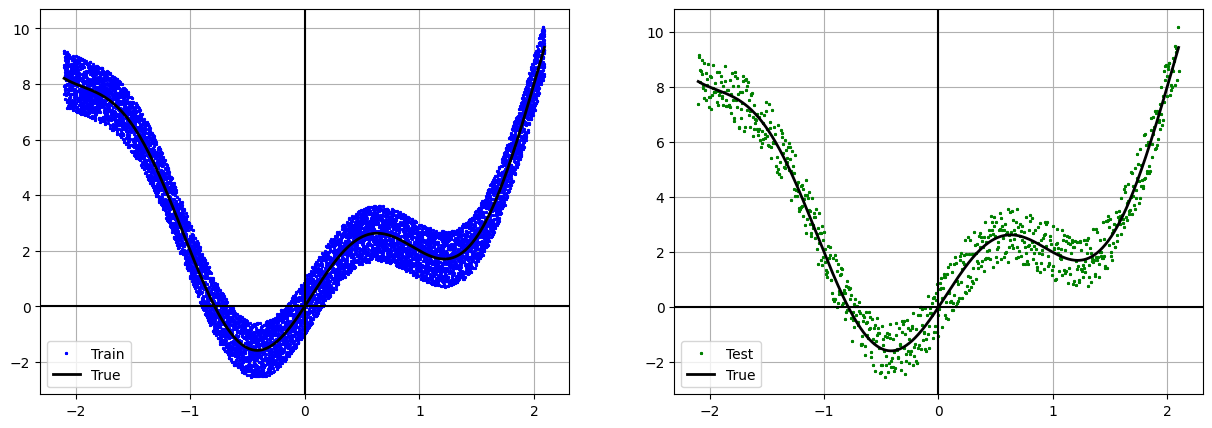

In [48]:
fig, axes = plt.subplots(1, 2, figsize =(15,5))

ax = axes[0]
ax.plot(X_train, y_train, 'b*', markersize=2, label = 'Train')
ax.plot(X_train,  y_true, c = 'k', linewidth=2, label = 'True')
ax.axhline(0, c = 'k')
ax.axvline(0, c = 'k')
ax.grid()
ax.legend()

ax = axes[1]
ax.plot(X_test, y_test, 'g*', markersize=2, label = 'Test')
ax.plot(X_test,  y_true_test, c = 'k', linewidth=2, label = 'True')
ax.axhline(0, c = 'k')
ax.axvline(0, c = 'k')
ax.grid()
ax.legend();

In [49]:
# What shape of Input layer?
num_features = 1

#initializer = tf.keras.initializers.HeNormal(seed = RANDOM_STATE)

# Define Model

# Define the input layer
input_layer = tf.keras.layers.Input(shape=(num_features,))  # Assuming input shape is (784,)

# Add a hidden layer with 128 neurons and ReLU activation
hidden_layer = tf.keras.layers.Dense(128, activation='relu')(input_layer)

# Add another hidden layer with 64 neurons and ReLU activation
hidden_layer = tf.keras.layers.Dense(64, activation='relu')(hidden_layer)

# Add the output layer with 10 neurons (for a classification task) and softmax activation
output_layer = tf.keras.layers.Dense(1)(hidden_layer)

# Create the model by specifying the input and output layers
model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

In [50]:
# Compile the model with a specific optimizer, loss function, and metrics

model.compile(optimizer='adam', 
              loss='mean_squared_error', 
              metrics=['mae'])

In [51]:
# fit the model
history = model.fit(X_train, y_train, 
                    batch_size = BATCH_SIZE,
                    validation_data=[X_test, y_test],
                    epochs=EPOCHS, 
                    verbose=2)

Epoch 1/50


I0000 00:00:1778640568.522684   16450 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33422__.8


131/131 - 2s - 12ms/step - loss: 5.6704 - mae: 1.8425 - val_loss: 2.4747 - val_mae: 1.2946
Epoch 2/50
131/131 - 0s - 2ms/step - loss: 1.6949 - mae: 1.0381 - val_loss: 1.2339 - val_mae: 0.8465
Epoch 3/50
131/131 - 0s - 2ms/step - loss: 1.1794 - mae: 0.8378 - val_loss: 1.1509 - val_mae: 0.8194
Epoch 4/50
131/131 - 0s - 2ms/step - loss: 1.0831 - mae: 0.8060 - val_loss: 1.0355 - val_mae: 0.7856
Epoch 5/50
131/131 - 0s - 2ms/step - loss: 0.9486 - mae: 0.7619 - val_loss: 0.8789 - val_mae: 0.7353
Epoch 6/50
131/131 - 0s - 2ms/step - loss: 0.7881 - mae: 0.7036 - val_loss: 0.7115 - val_mae: 0.6723
Epoch 7/50
131/131 - 0s - 2ms/step - loss: 0.6342 - mae: 0.6409 - val_loss: 0.5664 - val_mae: 0.6150
Epoch 8/50
131/131 - 0s - 2ms/step - loss: 0.5158 - mae: 0.5885 - val_loss: 0.4655 - val_mae: 0.5718
Epoch 9/50
131/131 - 0s - 2ms/step - loss: 0.4417 - mae: 0.5538 - val_loss: 0.4084 - val_mae: 0.5434
Epoch 10/50
131/131 - 0s - 2ms/step - loss: 0.4030 - mae: 0.5343 - val_loss: 0.3817 - val_mae: 0.5274

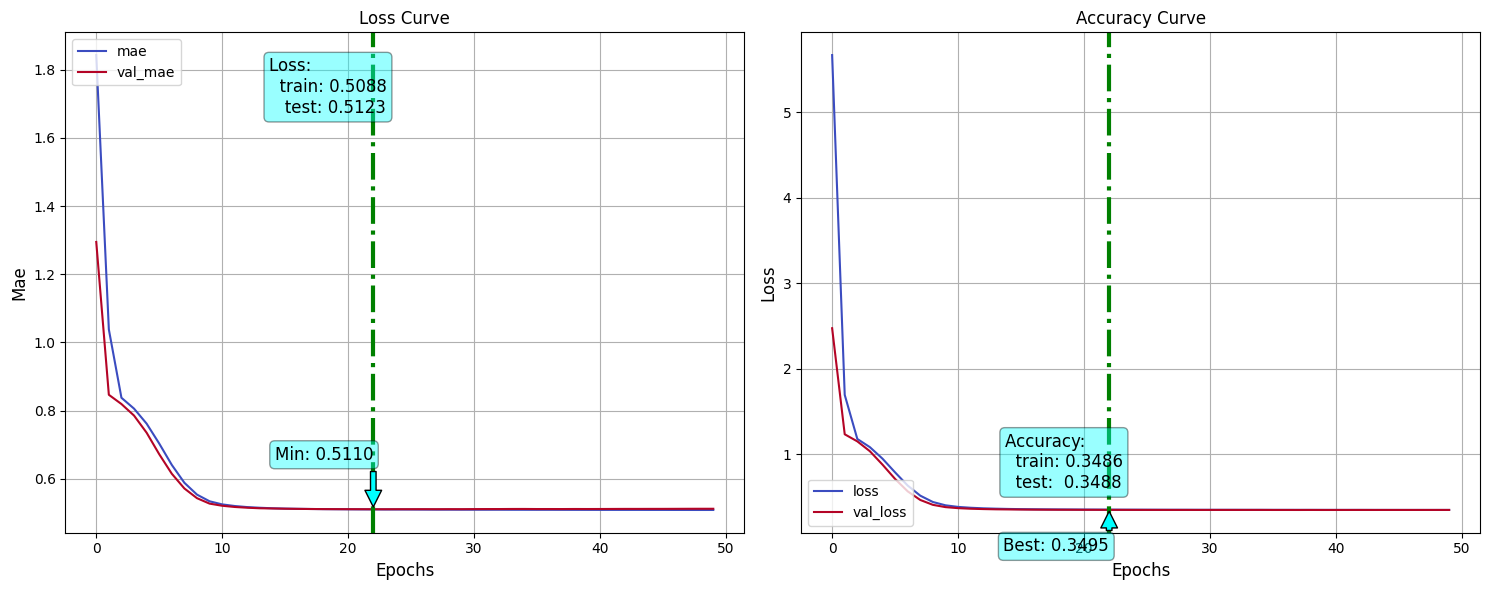

In [52]:
hist_df = pd.DataFrame(history.history)

fn_plot_tf_hist(hist_df)

In [53]:
# evaluate the model
error = model.evaluate(X_test, y_test, verbose=0)

print(f'Loss: {error[0]:.3f}, MAE: {np.sqrt(error[1]):.3f}')

Loss: 0.349, MAE: 0.716


In [54]:
y_pred = model.predict(X_test)

results_df = pd.DataFrame({'pred' : y_pred[:,0], 'test' : y_test} )

results_df['y_true'] = y_true_test

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


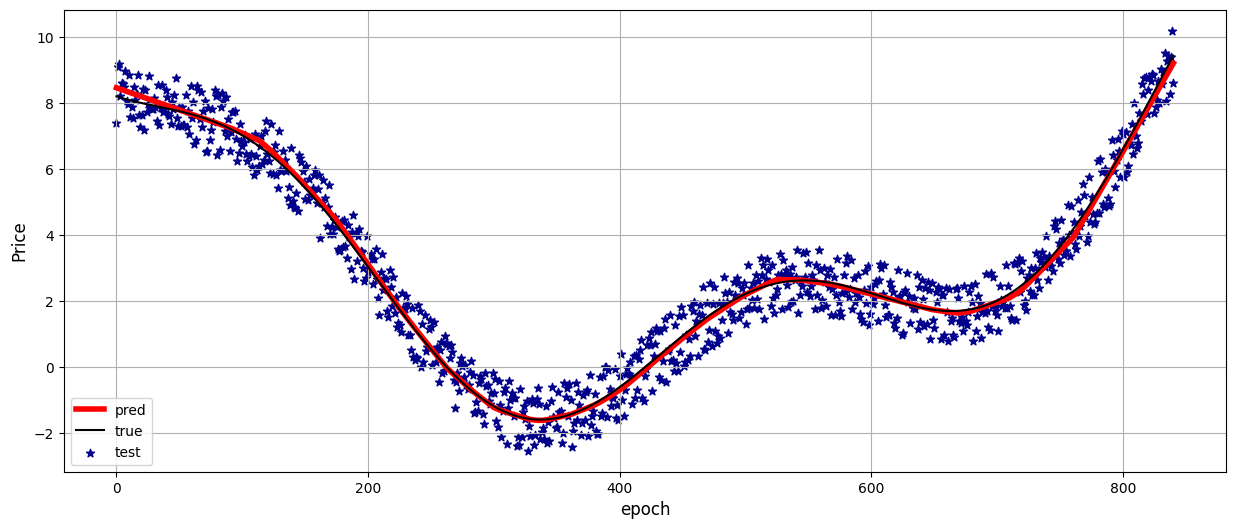

In [55]:
ax = results_df.pred.plot(c = 'r', label = 'pred', lw = 4);
results_df.y_true.plot(c = 'k', ax = ax, label = 'true')

ax.scatter(results_df.index, results_df.test, c='DarkBlue', marker ='*', label = 'test');

ax.set_xlabel("epoch")
ax.set_ylabel("Price")
ax.grid()
plt.legend()
plt.show()